We will implement KNN on a heart disease dataset. We will explore data, preprocess data, then find the best K and train our model on the dataset.
The problem with this dataset is that it has a lot of duplicate rows. In the code we will remove them to get better K.

# Our first step is to get the dataset from GitHub.

First, we will import necessary packages.

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)
from sklearn.decomposition import PCA

Now, we will get our dataset from github.

In [77]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/mdraihan27/svm-and-knn/refs/heads/main/heart.csv"

df = pd.read_csv(GITHUB_RAW_URL)

print("Dataset loaded successfully from GitHub!")
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nTarget Column — 'target' value counts:")
print(df['target'].value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully from GitHub!

Shape: 1025 rows x 14 columns

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Target Column — 'target' value counts:
target
1    526
0    499
Name: count, dtype: int64

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Now, we will explore our dataset.

Let's start with analyzing the amount missing values and view basic stats.

---



In [78]:
print("\nData Types and Non-Null Counts:")
print(df.info())

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()


Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing Values Per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope     

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Lets visualize class distribution.

/tmp/ipykernel_1504/3288697022.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Blues')


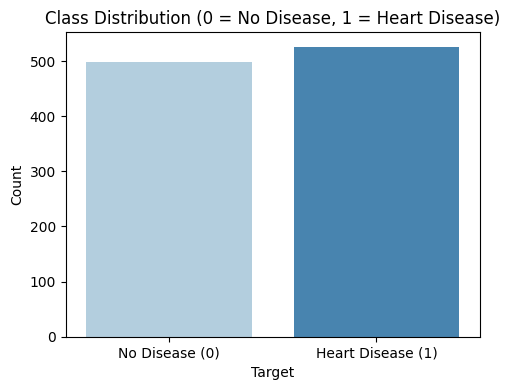


Class Balance:
No Heart Disease (0): 499 samples
Heart Disease    (1): 526 samples


In [79]:
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df, palette='Blues')
plt.title('Class Distribution (0 = No Disease, 1 = Heart Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease (0)', 'Heart Disease (1)'])
plt.tight_layout()
plt.show()

print("\nClass Balance:")
print(f"No Heart Disease (0): {df['target'].value_counts()[0]} samples")
print(f"Heart Disease    (1): {df['target'].value_counts()[1]} samples")

Let's view histogram of how widely distributed features affect our target.

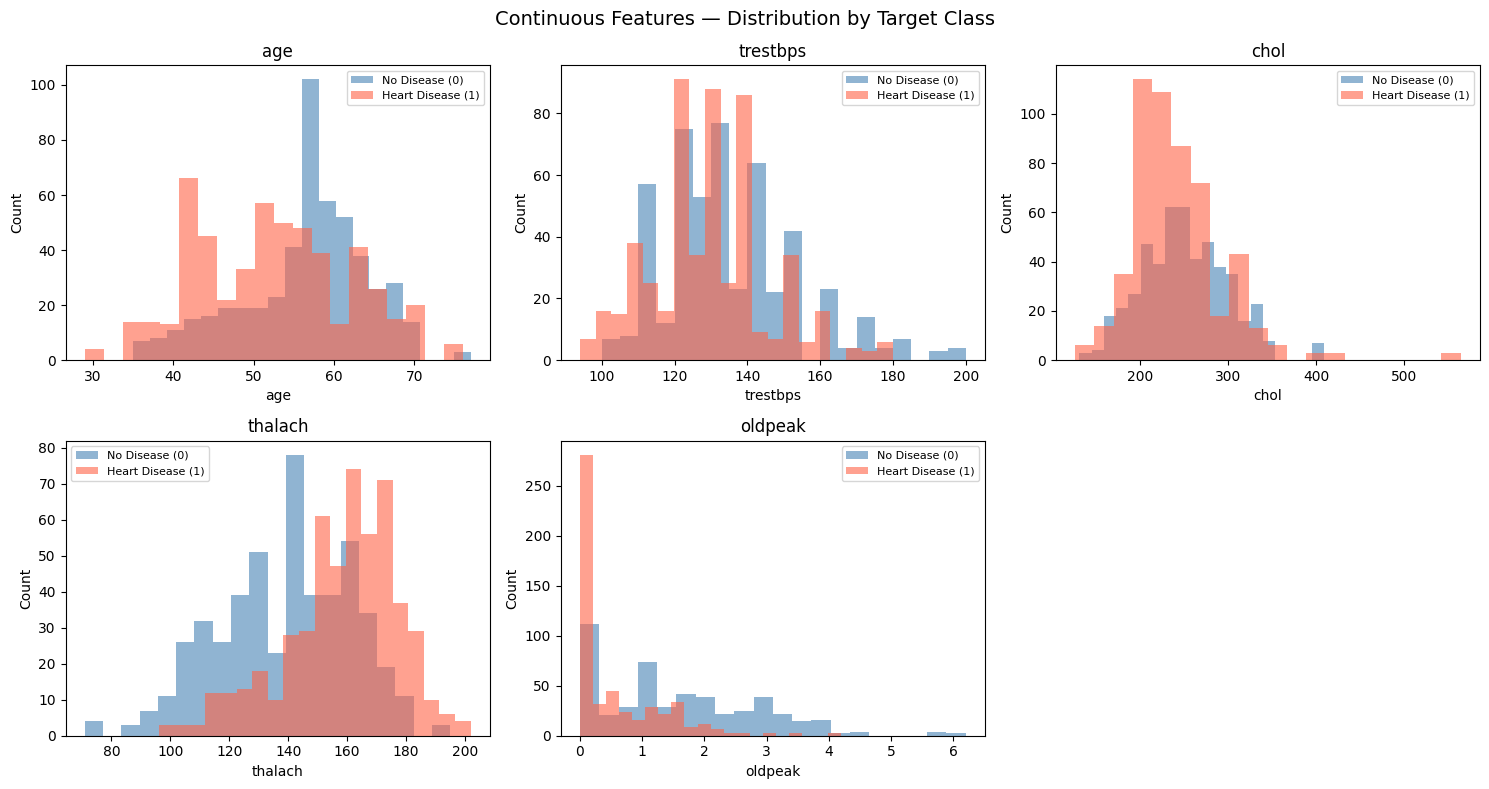

In [80]:
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous):
    axes[i].hist(df[df['target'] == 0][col], bins=20, alpha=0.6,
                 color='steelblue', label='No Disease (0)')
    axes[i].hist(df[df['target'] == 1][col], bins=20, alpha=0.6,
                 color='tomato', label='Heart Disease (1)')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

fig.delaxes(axes[5])

plt.suptitle('Continuous Features — Distribution by Target Class', fontsize=14)
plt.tight_layout()
plt.savefig('continuous_distributions.png', dpi=150)
plt.show()

We can conclude that

Let's see how categorical features affect our target.

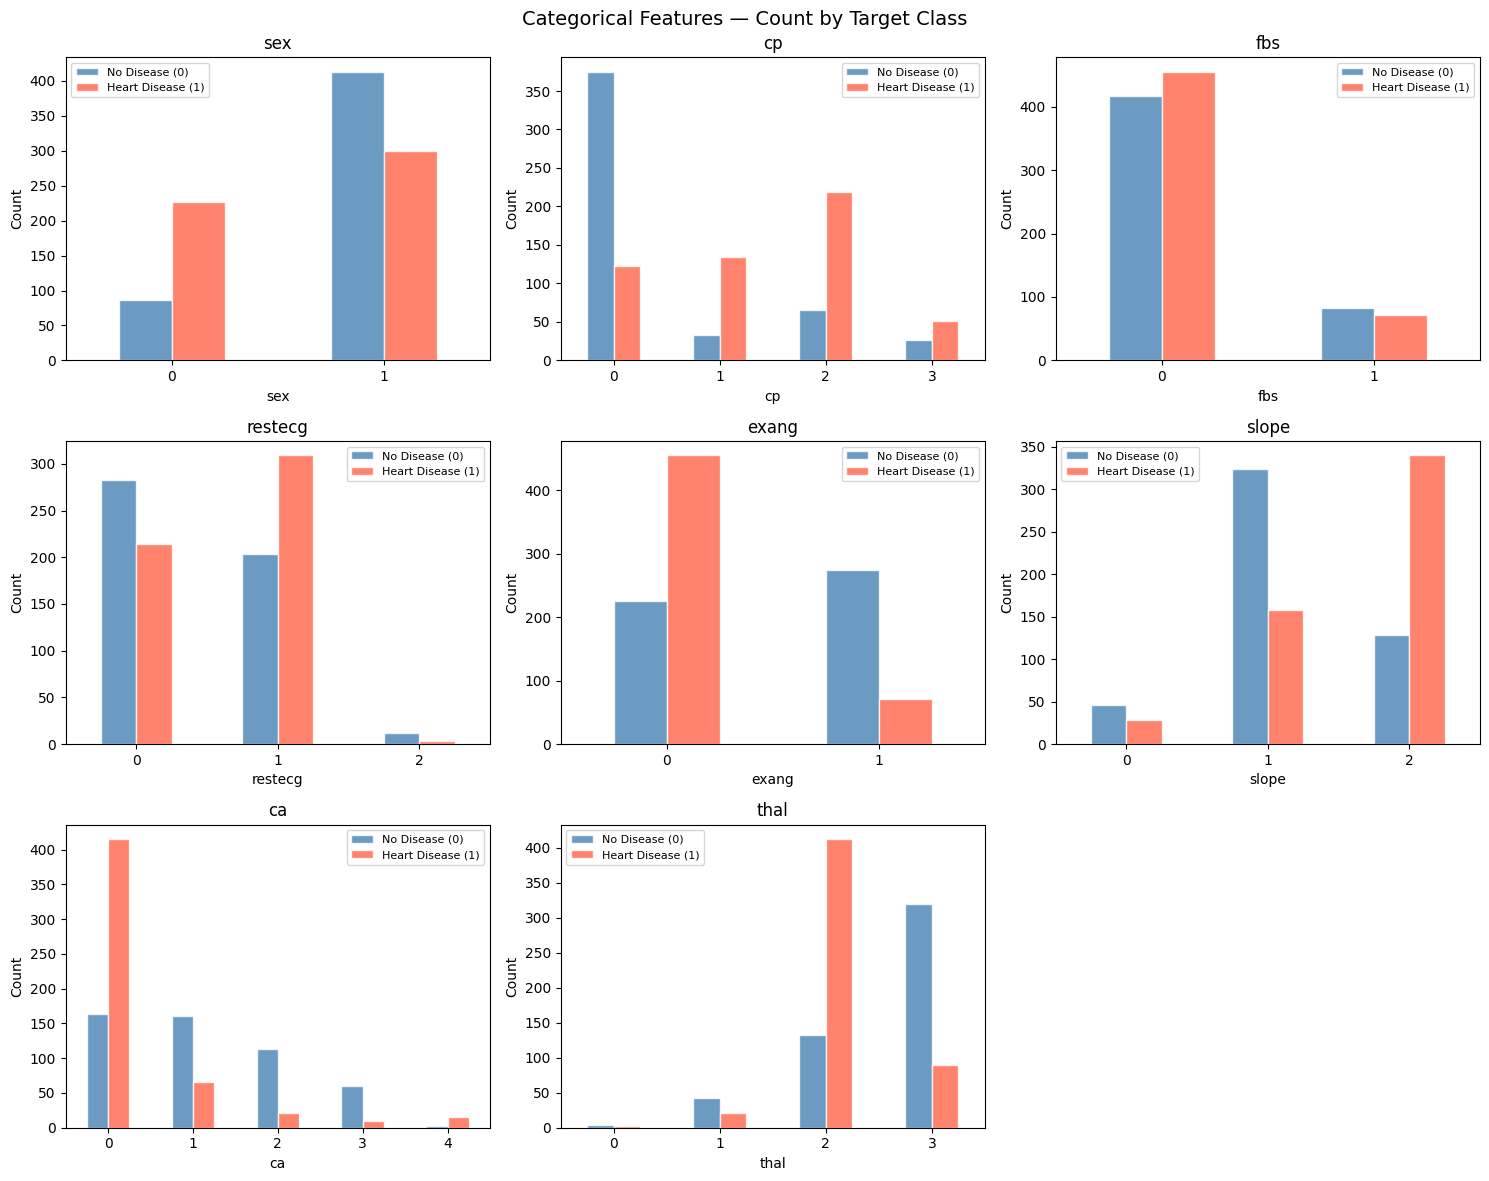

In [81]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(categorical):
    counts = df.groupby([col, 'target']).size().unstack(fill_value=0)
    counts.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
                alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease (0)', 'Heart Disease (1)'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

fig.delaxes(axes[8])

plt.suptitle('Categorical Features — Count by Target Class', fontsize=14)
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150)
plt.show()

I can conclude by the histograms that,
1. Females have more chance to geat heart disease.
2. cp in negatively related with heart disease.
3. fbs seems to have no effect
4. ca and exang has negative effect, the more it is , the less chance of heart disease.
5. slope has positive effect.
6. The other features have somewhat effect.

Let's view the correlation heatmap to understand relationships between target and features more.

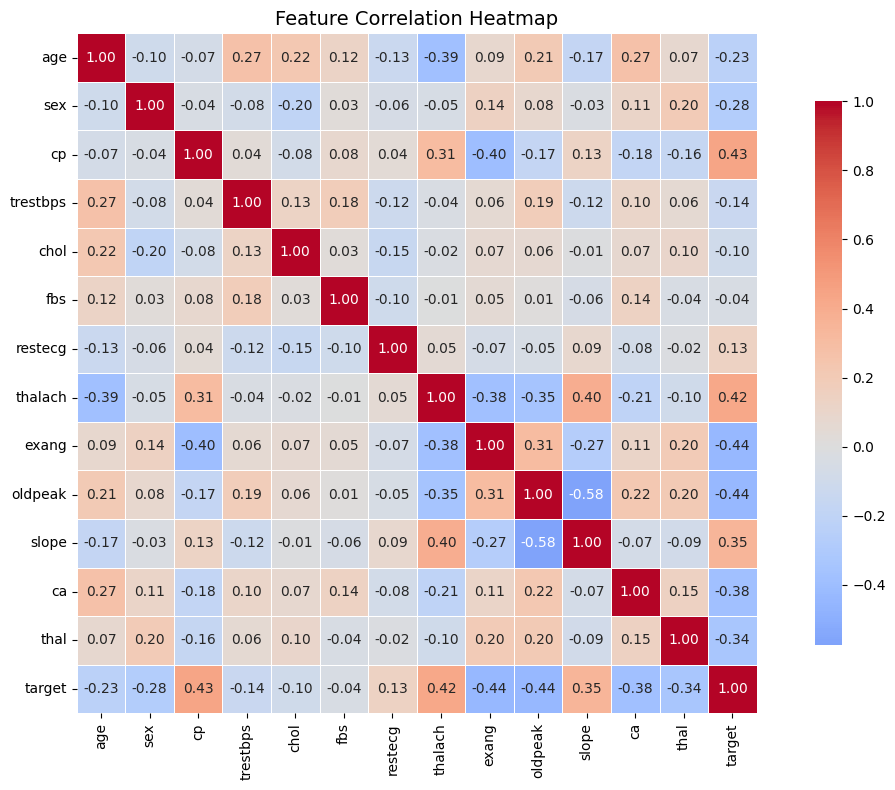

In [82]:
plt.figure(figsize=(12, 8))
correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

Let's view some scatter plots.

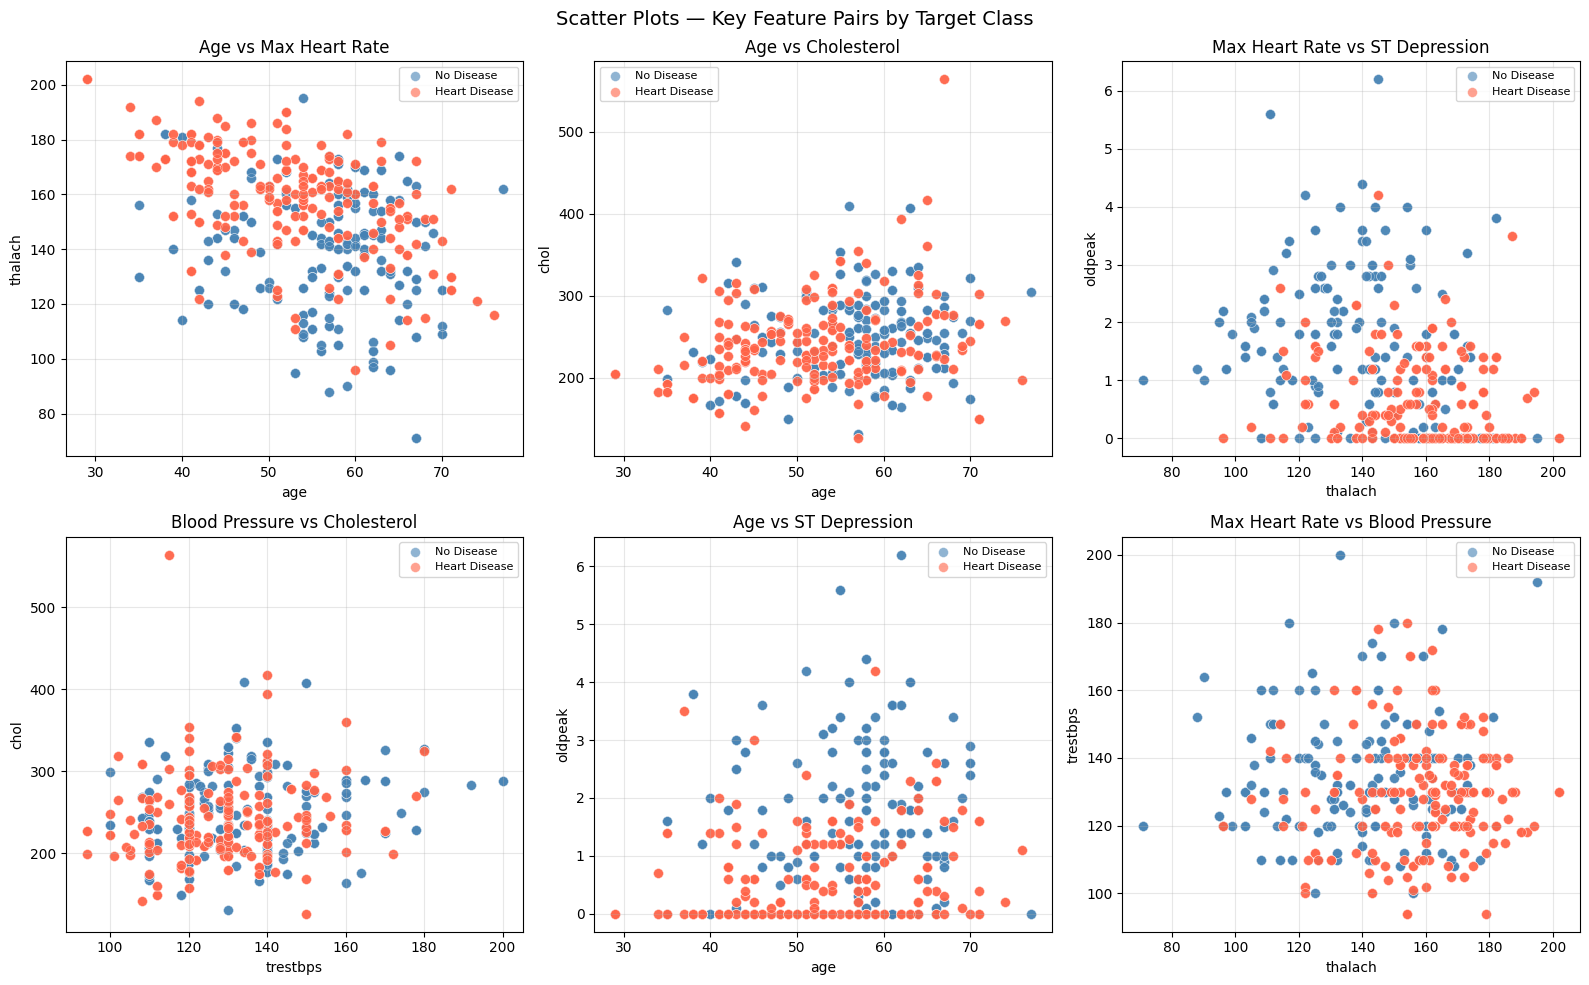

In [83]:
scatter_pairs = [
    ('age',      'thalach',  'Age vs Max Heart Rate'),
    ('age',      'chol',     'Age vs Cholesterol'),
    ('thalach',  'oldpeak',  'Max Heart Rate vs ST Depression'),
    ('trestbps', 'chol',     'Blood Pressure vs Cholesterol'),
    ('age',      'oldpeak',  'Age vs ST Depression'),
    ('thalach',  'trestbps', 'Max Heart Rate vs Blood Pressure'),
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, (x_col, y_col, title) in enumerate(scatter_pairs):
    for target_val, color, label in [(0, 'steelblue', 'No Disease'),
                                      (1, 'tomato',    'Heart Disease')]:
        subset = df[df['target'] == target_val]
        axes[i].scatter(
            subset[x_col],
            subset[y_col],
            c=color,
            label=label,
            alpha=0.6,
            edgecolors='white',
            linewidths=0.4,
            s=50
        )
    axes[i].set_title(title, fontsize=12)
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Scatter Plots — Key Feature Pairs by Target Class', fontsize=14)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150)
plt.show()

# Now, we will perform data preprocessing.

First, we will handle missing values.

In [84]:
print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

df.dropna(inplace=True)

print(f"\nAfter dropping nulls — Total missing values: {df.isnull().sum().sum()}")
print(f"Dataset shape after cleaning: {df.shape}")


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

After dropping nulls — Total missing values: 0
Dataset shape after cleaning: (1025, 14)


There are a lot of duplicates in out dataset, so now, we will remove the duplicates.

In [85]:

print(f"Rows before: {df.shape[0]}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows after:  {df.shape[0]}")
print(f"Duplicates removed: {1025 - df.shape[0]}")

Rows before: 1025
Rows after:  302
Duplicates removed: 723


Let's encode categorical data.

In [86]:
print("STEP 2 — Encoding Categorical Features")
print("=" * 40)

print("\nData types of each column:")
print(df.dtypes)

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(cat_cols) == 0:
    print("\nNo categorical columns found.")
    print("All columns are already numeric — no encoding required.")
else:
    print(f"\nCategorical columns found: {cat_cols}")
    for col in cat_cols:
        df = pd.get_dummies(df, columns=[col], drop_first=True)
        print(f"One-Hot Encoded: {col}")

print(f"\nDataset shape after encoding: {df.shape}")
print(f"\nColumns after encoding:")
print(df.columns.tolist())

STEP 2 — Encoding Categorical Features

Data types of each column:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

No categorical columns found.
All columns are already numeric — no encoding required.

Dataset shape after encoding: (302, 14)

Columns after encoding:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


Our dataset does not have any categorical data, so no encoding is required.

# Train/Validation/Test split.

In [87]:
X = df.drop('target', axis=1)
y = df['target']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target   (y) shape: {y.shape}")

print(f"\nTarget class distribution before split:")
print(y.value_counts())

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nSplit results:")
print(f"Training   set: {X_train.shape[0]} samples (70%)")
print(f"Validation set: {X_val.shape[0]} samples (15%)")
print(f"Test       set: {X_test.shape[0]} samples (15%)")

print(f"\nClass distribution in each split:")
print(f"\nTraining set:\n{y_train.value_counts()}")
print(f"\nValidation set:\n{y_val.value_counts()}")
print(f"\nTest set:\n{y_test.value_counts()}")


Features (X) shape: (302, 13)
Target   (y) shape: (302,)

Target class distribution before split:
target
1    164
0    138
Name: count, dtype: int64

Split results:
Training   set: 211 samples (70%)
Validation set: 45 samples (15%)
Test       set: 46 samples (15%)

Class distribution in each split:

Training set:
target
1    115
0     96
Name: count, dtype: int64

Validation set:
target
1    24
0    21
Name: count, dtype: int64

Test set:
target
1    25
0    21
Name: count, dtype: int64


Let's scale our features.

In [88]:
print("\nFeature ranges BEFORE scaling:")
print(pd.DataFrame(X_train).describe().round(2))

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("\nFeature ranges AFTER scaling:")
print(pd.DataFrame(X_train).describe().round(2))

print("\nScaling complete!")


Feature ranges BEFORE scaling:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  211.00  211.00  211.00    211.00  211.00  211.00   211.00   211.00   
mean    54.20    0.66    1.00    131.68  246.72    0.14     0.52   152.00   
std      9.19    0.48    1.03     16.66   53.49    0.35     0.54    22.39   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  210.50    0.00     0.00   140.00   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   155.00   
75%     60.00    1.00    2.00    140.00  279.50    0.00     1.00   169.00   
max     77.00    1.00    3.00    192.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  
count  211.00   211.00  211.00  211.00  211.00  
mean     0.29     0.98    1.43    0.79    2.30  
std      0.45     1.17    0.62    1.07    0.62  
min      0.00     0.00    0.00    0.00    0.00  
25%      0.00     0.00    1.0

# Before running the model, we need to find the best K for our task.

First, we will use elbow method.

In [89]:
from sklearn.model_selection import cross_val_score

error_rates = []
accuracy_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_val)
    error_rates.append(1 - accuracy_score(y_val, preds))
    accuracy_rates.append(accuracy_score(y_val, preds))

print("\nK Value | Accuracy | Error Rate")
print("-" * 35)
for k, acc, err in zip(k_range, accuracy_rates, error_rates):
    print(f"K = {k:<5} | {acc*100:.2f}%    | {err:.4f}")

optimal_k = list(k_range)[np.argmin(error_rates)]
print(f"\nOptimal K from Elbow Method: {optimal_k}")
print(f"Best Validation Accuracy:    {max(accuracy_rates)*100:.2f}%")


K Value | Accuracy | Error Rate
-----------------------------------
K = 1     | 77.78%    | 0.2222
K = 2     | 82.22%    | 0.1778
K = 3     | 82.22%    | 0.1778
K = 4     | 82.22%    | 0.1778
K = 5     | 80.00%    | 0.2000
K = 6     | 84.44%    | 0.1556
K = 7     | 82.22%    | 0.1778
K = 8     | 82.22%    | 0.1778
K = 9     | 80.00%    | 0.2000
K = 10    | 77.78%    | 0.2222
K = 11    | 82.22%    | 0.1778
K = 12    | 84.44%    | 0.1556
K = 13    | 86.67%    | 0.1333
K = 14    | 84.44%    | 0.1556
K = 15    | 84.44%    | 0.1556
K = 16    | 84.44%    | 0.1556
K = 17    | 84.44%    | 0.1556
K = 18    | 84.44%    | 0.1556
K = 19    | 84.44%    | 0.1556
K = 20    | 84.44%    | 0.1556
K = 21    | 82.22%    | 0.1778
K = 22    | 82.22%    | 0.1778
K = 23    | 84.44%    | 0.1556
K = 24    | 84.44%    | 0.1556
K = 25    | 84.44%    | 0.1556
K = 26    | 82.22%    | 0.1778
K = 27    | 82.22%    | 0.1778
K = 28    | 82.22%    | 0.1778
K = 29    | 84.44%    | 0.1556
K = 30    | 84.44%    | 0.1556



Let's plot the error rate and accuracy by optimal K value.

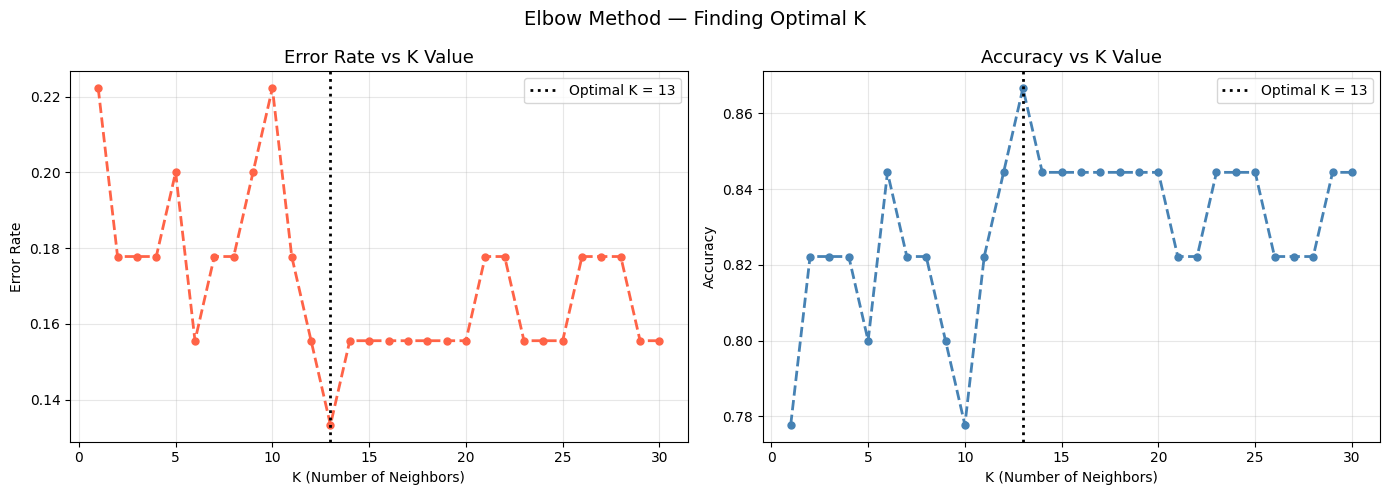

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), error_rates, marker='o', color='tomato',
             linestyle='--', linewidth=2, markersize=5)
axes[0].axvline(x=optimal_k, color='black', linestyle=':', linewidth=2,
                label=f'Optimal K = {optimal_k}')
axes[0].set_title('Error Rate vs K Value', fontsize=13)
axes[0].set_xlabel('K (Number of Neighbors)')
axes[0].set_ylabel('Error Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), accuracy_rates, marker='o', color='steelblue',
             linestyle='--', linewidth=2, markersize=5)
axes[1].axvline(x=optimal_k, color='black', linestyle=':', linewidth=2,
                label=f'Optimal K = {optimal_k}')
axes[1].set_title('Accuracy vs K Value', fontsize=13)
axes[1].set_xlabel('K (Number of Neighbors)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Elbow Method — Finding Optimal K', fontsize=14)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

Let's perform hyperparameter tuning with grid search to get the optimal K.

In [91]:
param_grid = {
    'n_neighbors' : list(range(5, 21)),
    'weights'     : ['uniform', 'distance'],
    'metric'      : ['minkowski', 'euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"\nBest Parameters  : {grid.best_params_}")
print(f"Best CV Accuracy : {round(grid.best_score_ * 100, 2)}%")

Fitting 10 folds for each of 96 candidates, totalling 960 fits

Best Parameters  : {'metric': 'minkowski', 'n_neighbors': 8, 'weights': 'distance'}
Best CV Accuracy : 85.78%


# Now we will perform final training with the best K we have achieved.

In [92]:
best_knn = grid.best_estimator_

best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:, 1]

print(f"Best Parameters used: {grid.best_params_}")
print(f"\nModel trained successfully!")
print(f"\nTest Set Results:")
print(f"Total test samples : {len(y_test)}")
print(f"Correct predictions: {sum(y_pred == y_test)}")
print(f"Wrong predictions  : {sum(y_pred != y_test)}")
print(f"\nTest Accuracy: {round(accuracy_score(y_test, y_pred) * 100, 2)}%")

Best Parameters used: {'metric': 'minkowski', 'n_neighbors': 8, 'weights': 'distance'}

Model trained successfully!

Test Set Results:
Total test samples : 46
Correct predictions: 36
Wrong predictions  : 10

Test Accuracy: 78.26%


# Lets see some metrics on our models accuracy.

First we will see confusion matrix.

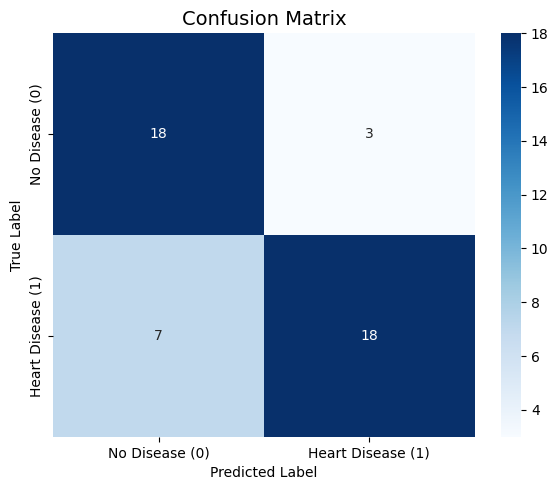

True Negatives  (Correctly predicted No Disease) : 18
False Positives (Predicted Disease, actually not): 3
False Negatives (Missed actual Disease cases)    : 7
True Positives  (Correctly predicted Disease)    : 18


In [93]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Heart Disease (1)'],
            yticklabels=['No Disease (0)', 'Heart Disease (1)'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correctly predicted No Disease) : {tn}")
print(f"False Positives (Predicted Disease, actually not): {fp}")
print(f"False Negatives (Missed actual Disease cases)    : {fn}")
print(f"True Positives  (Correctly predicted Disease)    : {tp}")

Lets print evaluation metrics.

In [94]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease (0)', 'Heart Disease (1)']))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"Accuracy  : {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
print(f"AUC Score : {round(roc_auc, 4)}")


Classification Report:
                   precision    recall  f1-score   support

   No Disease (0)       0.72      0.86      0.78        21
Heart Disease (1)       0.86      0.72      0.78        25

         accuracy                           0.78        46
        macro avg       0.79      0.79      0.78        46
     weighted avg       0.79      0.78      0.78        46

Accuracy  : 78.26%
AUC Score : 0.8495


Let's print the ROC curve.

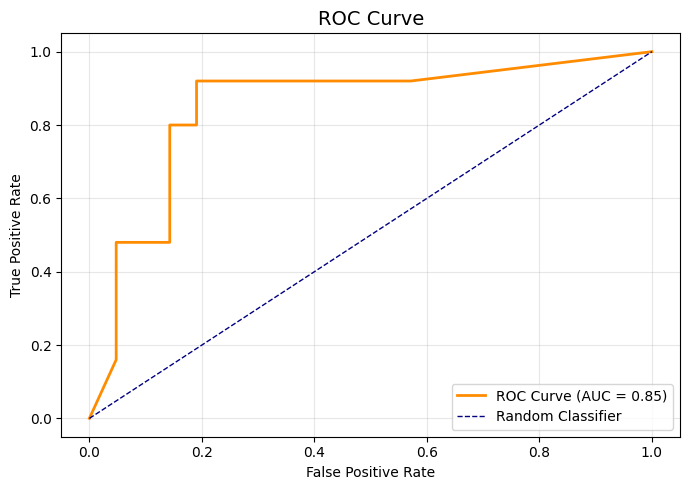


AUC Score: 0.8495
AUC closer to 1.0 means better model performance.
AUC of 0.5 means the model is no better than random guessing.


In [95]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1,
         linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"\nAUC Score: {round(roc_auc, 4)}")
print("AUC closer to 1.0 means better model performance.")
print("AUC of 0.5 means the model is no better than random guessing.")

Let's see the 2d decision boundary.

Variance explained by 2 components: 32.82%


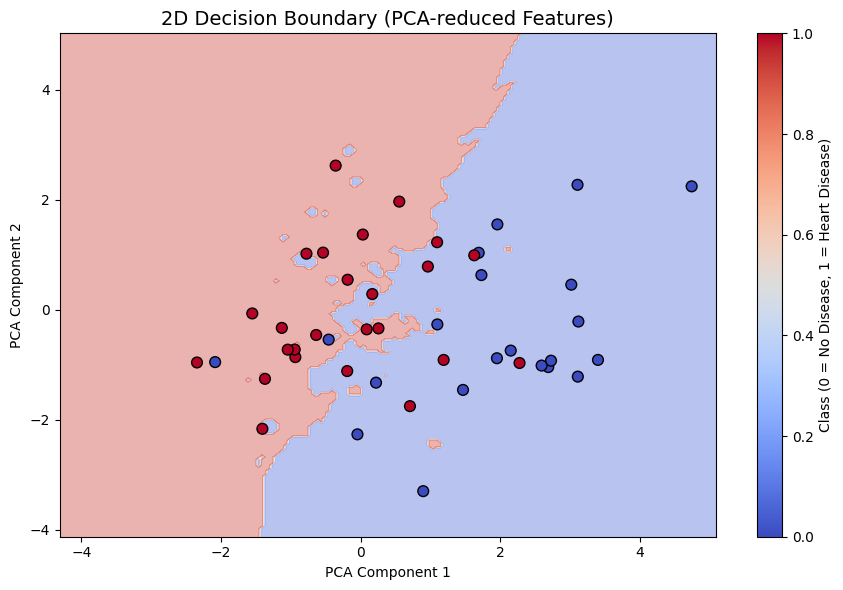

In [96]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

print(f"Variance explained by 2 components: "
      f"{round(sum(pca.explained_variance_ratio_) * 100, 2)}%")

knn_2d = KNeighborsClassifier(**grid.best_params_)
knn_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                      c=y_test, cmap='coolwarm',
                      edgecolors='k', s=60)
plt.title('2D Decision Boundary (PCA-reduced Features)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Class (0 = No Disease, 1 = Heart Disease)')
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150)
plt.show()